In [ ]:
! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
! pip install pandas
! pip install scikit-learn
! pip install xgboost shap
! pip install yfinance

Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 31.7 MB/s eta 0:01:18
     ---------------------------------------- 0.0/2.4 GB 41.8 MB/s eta 0:00:59
     ---------------------------------------- 0.0/2.4 GB 24.7 MB/s eta 0:01:40
     ---------------------------------------- 0.0/2.4 GB 19.7 MB/s eta 0:02:05
     ---------------------------------------- 0.0/2.4 GB 15.4 MB/s eta 0:02:39
     ---------------------------------------- 0.0/2.4 GB 12.7 MB/s eta 0:03:13
     ---------------------------------------- 0.0/2.4 GB 12.7 MB/s eta 0:03:13
     ---------------------------------------- 0.0/2.4 GB 9.8 MB/s eta 0:04:10
     ---------------------------------------- 0.0/2.4 GB 9.2 MB/s eta 0:04:28
     ---------------------------------------- 0.0/2.4 GB 8.3 MB/s eta 0:04:54
     ---------------------------------------- 0.0/2.4 GB 7.7 MB/s eta 0:05:18
     

In [62]:
! pip install transformers

     ---------------------------------------- 0.0/41.4 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.4 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.4 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 41.4/41.4 kB 286.2 kB/s eta 0:00:00
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     -------------------------------------- 41.5/41.5 kB 977.7 kB/s eta 0:00:00
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.0 MB 3.8 MB/s eta 0:00:04
    --------------------------------------- 0.2/12.0 MB 3.4 MB/s eta 0:00:04
   - -------------------------------------- 0.4/12.0 MB 3.8 MB/s eta 0:00:04
   --- ------------------------------------ 1.1/12.0 MB 6.7 MB/s eta 0:00:02
   ------ --------------------------------- 1.9/12.0 MB 9.5 MB/s eta 0:00:02
   -------- ----


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
! pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117


Looking in indexes: https://download.pytorch.org/whl/cu117



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("gold-dataset-sinha-khandait.csv")

# Show the first 5 rows
print(df.head())


        Dates                                                URL  \
0  28-01-2016  http://www.marketwatch.com/story/april-gold-do...   
1  13-09-2017  http://www.marketwatch.com/story/gold-prices-s...   
2  26-07-2016  http://www.marketwatch.com/story/gold-futures-...   
3  28-02-2018  https://www.metalsdaily.com/link/277199/dent-r...   
4  06-09-2017  http://www.marketwatch.com/story/gold-steadies...   

                                                News  Price Direction Up  \
0  april gold down 20 cents to settle at $1,116.1...                   0   
1          gold suffers third straight daily decline                   0   
2     Gold futures edge up after two-session decline                   1   
3  dent research : is gold's day in the sun comin...                   0   
4  Gold snaps three-day rally as Trump, lawmakers...                   0   

   Price Direction Constant  Price Direction Down  Asset Comparision  \
0                         0                     1             

In [34]:
df['Dates'] = pd.to_datetime(df['Dates'], dayfirst=True, errors='coerce')


In [35]:
df = df.dropna(subset=['Dates']).reset_index(drop=True)


In [36]:
df.head

<bound method NDFrame.head of            Dates                                                URL  \
0     2016-01-28  http://www.marketwatch.com/story/april-gold-do...   
1     2017-09-13  http://www.marketwatch.com/story/gold-prices-s...   
2     2016-07-26  http://www.marketwatch.com/story/gold-futures-...   
3     2018-02-28  https://www.metalsdaily.com/link/277199/dent-r...   
4     2017-09-06  http://www.marketwatch.com/story/gold-steadies...   
...          ...                                                ...   
10400 2013-01-07  https://www.moneycontrol.com/news/business/mar...   
10401 2018-09-27  https://www.metalsdaily.com/link/284468/domini...   
10402 2017-03-03  https://www.thehindubusinessline.com/markets/g...   
10403 2008-06-11  http://www.marketwatch.com/story/august-gold-u...   
10404 2007-10-01  http://www.marketwatch.com/story/december-gold...   

                                                    News  Price Direction Up  \
0      april gold down 20 cents to se

In [37]:
df.shape

(10405, 10)

In [38]:
# Sort in ascending order and update the same DataFrame
df.sort_values(by='Dates', ascending=True, inplace=True)

# Reset index if you want a clean sequential index
df.reset_index(drop=True, inplace=True)

In [39]:
df

,Dates,URL,News,Price Direction Up,Price Direction Constant,Price Direction Down,Asset Comparision,Past Information,Future Information,Price Sentiment
0,2000-02-15,http://www.marketwatch.com/story/thom-calandra...,gold is poised for greatness,1,0,0,0,1,0,positive
1,2000-02-17,http://www.marketwatch.com/story/gold-falls-on...,gold falls on technical pull back,0,0,1,0,1,0,negative
2,2000-03-24,http://www.marketwatch.com/story/gold-quiet-on...,gold quiet on lack of market news,0,1,0,0,1,0,neutral
3,2000-04-27,http://www.marketwatch.com/story/gold-futures-...,gold futures steady as index climbs,0,1,0,0,1,0,neutral
4,2000-05-04,http://www.marketwatch.com/story/gold-and-silv...,gold and silver stocks in relief rally,1,0,0,1,1,0,positive
...,...,...,...,...,...,...,...,...,...,...
10400,2019-01-28,https://www.thehindubusinessline.com/markets/g...,"Wedding buzz keeps gold firm at Rs 33,650",0,1,0,0,1,0,neutral
10401,2019-01-30,https://www.thehindubusinessline.com/markets/g...,Gold rises for 4th day in a row,1,0,0,0,1,0,positive
10402,2019-01-31,https://www.thehindubusinessline.com/markets/g...,India's 2019 gold demand forecast at 750-850 T...,0,0,0,0,1,0,none
10403,2019-01-31,https://www.thehindubusinessline.com/markets/g...,"Gold slips Rs 70 to Rs 34,000/10gm on muted de...",0,0,1,0,1,0,negative


In [40]:
import yfinance as yf
import pandas as pd

# Fetch historical gold ETF data
symbol = 'GLD'
gold_data = yf.download(symbol, start='2000-02-15', end='2019-02-01', auto_adjust=True)

# Keep only 'Close' column and reset index
gold_data = gold_data[['Close']].reset_index()

print(gold_data.head())


[*********************100%***********************]  1 of 1 completed

Price        Date      Close
Ticker                   GLD
0      2004-11-18  44.380001
1      2004-11-19  44.779999
2      2004-11-22  44.950001
3      2004-11-23  44.750000
4      2004-11-24  45.049999


In [41]:
df.columns

Index(['Dates', 'URL', 'News', 'Price Direction Up',
       'Price Direction Constant', 'Price Direction Down', 'Asset Comparision',
       'Past Information', 'Future Information', 'Price Sentiment'],
      dtype='object')

In [42]:
gold_data.columns

MultiIndex([( 'Date',    ''),
            ('Close', 'GLD')],
           names=['Price', 'Ticker'])

In [43]:
import pandas as pd

# Flatten gold_data columns
gold_data.columns = ['Date', 'Close']

# Ensure both date columns are datetime
df['Dates'] = pd.to_datetime(df['Dates'])
gold_data['Date'] = pd.to_datetime(gold_data['Date'])

# Merge on date
df_merged = pd.merge(df, gold_data, left_on='Dates', right_on='Date', how='inner')

# Keep only needed columns and rename
df_merged = df_merged[['Date', 'News', 'Close']]

print(df_merged.head())


        Date                                               News      Close
0 2004-11-18  spot gold quoted at $442.10, unchanged from ne...  44.380001
1 2004-11-18  spot gold quoted at $442, down 10 cents from n...  44.380001
2 2004-11-19                      gold futures climb above $446  44.779999
3 2004-11-22   internet gold to buy remaining shrs of goldtrade  44.950001
4 2004-11-22                    gold prices edge closer to $450  44.950001


In [45]:
df_merged.columns

Index(['Date', 'News', 'Close'], dtype='object')

In [46]:
df = df_merged

In [47]:
df

,Date,News,Close
0,2004-11-18,"spot gold quoted at $442.10, unchanged from ne...",44.380001
1,2004-11-18,"spot gold quoted at $442, down 10 cents from n...",44.380001
2,2004-11-19,gold futures climb above $446,44.779999
3,2004-11-22,internet gold to buy remaining shrs of goldtrade,44.950001
4,2004-11-22,gold prices edge closer to $450,44.950001
...,...,...,...
9371,2019-01-25,Wedding season pushes gold prices by Rs 90 to ...,122.860001
9372,2019-01-28,"Wedding buzz keeps gold firm at Rs 33,650",123.290001
9373,2019-01-30,Gold rises for 4th day in a row,124.690002
9374,2019-01-31,India's 2019 gold demand forecast at 750-850 T...,124.750000


In [48]:
df.isnull

<bound method DataFrame.isnull of            Date                                               News       Close
0    2004-11-18  spot gold quoted at $442.10, unchanged from ne...   44.380001
1    2004-11-18  spot gold quoted at $442, down 10 cents from n...   44.380001
2    2004-11-19                      gold futures climb above $446   44.779999
3    2004-11-22   internet gold to buy remaining shrs of goldtrade   44.950001
4    2004-11-22                    gold prices edge closer to $450   44.950001
...         ...                                                ...         ...
9371 2019-01-25  Wedding season pushes gold prices by Rs 90 to ...  122.860001
9372 2019-01-28          Wedding buzz keeps gold firm at Rs 33,650  123.290001
9373 2019-01-30                    Gold rises for 4th day in a row  124.690002
9374 2019-01-31  India's 2019 gold demand forecast at 750-850 T...  124.750000
9375 2019-01-31  Gold slips Rs 70 to Rs 34,000/10gm on muted de...  124.750000

[9376 rows x 3 co

In [49]:
# Set 'Date' as index
df.set_index('Date', inplace=True)

print(df.head())


                                                         News      Close
Date                                                                    
2004-11-18  spot gold quoted at $442.10, unchanged from ne...  44.380001
2004-11-18  spot gold quoted at $442, down 10 cents from n...  44.380001
2004-11-19                      gold futures climb above $446  44.779999
2004-11-22   internet gold to buy remaining shrs of goldtrade  44.950001
2004-11-22                    gold prices edge closer to $450  44.950001


In [51]:
df.columns

Index(['News', 'Close'], dtype='object')

In [52]:
gold_data.columns

Index(['Date', 'Close'], dtype='object')

In [53]:
df = df.reset_index().rename(columns={'index': 'Date'})
print(df.head())


        Date                                               News      Close
0 2004-11-18  spot gold quoted at $442.10, unchanged from ne...  44.380001
1 2004-11-18  spot gold quoted at $442, down 10 cents from n...  44.380001
2 2004-11-19                      gold futures climb above $446  44.779999
3 2004-11-22   internet gold to buy remaining shrs of goldtrade  44.950001
4 2004-11-22                    gold prices edge closer to $450  44.950001


In [54]:
df['Date'] = pd.to_datetime(df['Date'])
gold_data['Date'] = pd.to_datetime(gold_data['Date'])


In [55]:
df = df.sort_values('Date').reset_index(drop=True)
gold_data = gold_data.sort_values('Date').reset_index(drop=True)


In [56]:
gold_data['Next_Day_Close'] = gold_data['Close'].shift(-1)


In [57]:
df = pd.merge(df, gold_data[['Date', 'Next_Day_Close']], on='Date', how='left')
print(df.head())


        Date                                               News      Close  \
0 2004-11-18  spot gold quoted at $442.10, unchanged from ne...  44.380001   
1 2004-11-18  spot gold quoted at $442, down 10 cents from n...  44.380001   
2 2004-11-19                      gold futures climb above $446  44.779999   
3 2004-11-22   internet gold to buy remaining shrs of goldtrade  44.950001   
4 2004-11-22                    gold prices edge closer to $450  44.950001   

   Next_Day_Close  
0       44.779999  
1       44.779999  
2       44.950001  
3       44.750000  
4       44.750000  


In [58]:
df.columns

Index(['Date', 'News', 'Close', 'Next_Day_Close'], dtype='object')

In [59]:
df['Target'] = df['Next_Day_Close']


In [60]:
df['Price_Direction'] = df['Next_Day_Close'] - df['Close']
df['Target'] = df['Price_Direction'].apply(lambda x: 1 if x > 0 else 0)  # 1=up, 0=down


In [66]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load model and tokenizer
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')
model = BertForSequenceClassification.from_pretrained(
    'yiyanghkust/finbert-tone',
    torch_dtype=torch.float32,
    use_safetensors=True
)



`torch_dtype` is deprecated! Use `dtype` instead!


In [61]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cuda


In [67]:
model = model.to(device)


In [68]:
def get_finbert_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    # Move inputs to GPU
    inputs = {key: val.to(device) for key, val in inputs.items()}
    
    with torch.no_grad():
        logits = model(**inputs).logits
    
    probs = torch.nn.functional.softmax(logits, dim=-1)
    sentiment = torch.argmax(probs).item()
    
    sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    return sentiment_map[sentiment], probs[0][sentiment].item()


In [69]:
df['sentiment_label'], df['sentiment_score'] = zip(*df['News'].apply(get_finbert_sentiment))


In [70]:
df.columns

Index(['Date', 'News', 'Close', 'Next_Day_Close', 'Target', 'Price_Direction',
       'sentiment_label', 'sentiment_score'],
      dtype='object')

In [71]:
# Lag features of sentiment
df['sentiment_lag1'] = df['sentiment_score'].shift(1)
df['sentiment_lag2'] = df['sentiment_score'].shift(2)

# Rolling mean of sentiment (last 3 days)
df['sentiment_roll3'] = df['sentiment_score'].rolling(window=3).mean()

# Optional: Rolling std for sentiment volatility
df['sentiment_std3'] = df['sentiment_score'].rolling(window=3).std()

# Lag features for Close price (helpful for regression)
df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)

# Optional: Rolling mean of Close (last 3 days)
df['Close_roll3'] = df['Close'].rolling(window=3).mean()

# Drop initial rows with NaN from lag/rolling
df = df.dropna().reset_index(drop=True)

print(df.head())


        Date                                               News      Close  \
0 2004-11-19                      gold futures climb above $446  44.779999   
1 2004-11-22   internet gold to buy remaining shrs of goldtrade  44.950001   
2 2004-11-22                    gold prices edge closer to $450  44.950001   
3 2004-11-23                  gold futures close modestly lower  44.750000   
4 2004-11-23  gold futures continue lower in late morning trade  44.750000   

   Next_Day_Close  Target  Price_Direction sentiment_label  sentiment_score  \
0       44.950001       1         0.170002         neutral         1.000000   
1       44.750000       0        -0.200001        negative         0.996560   
2       44.750000       0        -0.200001         neutral         0.925013   
3       45.049999       1         0.299999         neutral         0.890138   
4       45.049999       1         0.299999        positive         0.999424   

   sentiment_lag1  sentiment_lag2  sentiment_roll3  sent

In [72]:
df.columns

Index(['Date', 'News', 'Close', 'Next_Day_Close', 'Target', 'Price_Direction',
       'sentiment_label', 'sentiment_score', 'sentiment_lag1',
       'sentiment_lag2', 'sentiment_roll3', 'sentiment_std3', 'Close_lag1',
       'Close_lag2', 'Close_roll3'],
      dtype='object')

In [74]:
# Example: train on 80% of the data, test on last 20%
split_index = int(len(df) * 0.8)
train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Features and target
features = ['sentiment_score', 'sentiment_lag1', 'sentiment_lag2', 
            'sentiment_roll3', 'sentiment_std3', 
            'Close_lag1', 'Close_lag2', 'Close_roll3']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

print(X_train.shape, X_test.shape)


(7497, 8) (1875, 8)


In [75]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


In [76]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


In [80]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
print("R2:", r2_score(y_test, y_pred))


RMSE: 0.6850790708621403
R2: -0.8813838775663785


In [81]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.5306666666666666
F1 Score: 0.5402298850574713


In [85]:
! pip install matplotlib


     ---------------------------------------- 0.0/114.6 kB ? eta -:--:--
     ---------- ---------------------------- 30.7/114.6 kB 1.4 MB/s eta 0:00:01
     -------------------------------------- 114.6/114.6 kB 1.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 14.2 MB/s eta 0:00:01
   ----- ---------------------------------- 1.1/8.1 MB 14.3 MB/s eta 0:00:01
   --------- ------------------------------ 1.8/8.1 MB 14.6 MB/s eta 0:00:01
   ------------- -------------------------- 2.7/8.1 MB 15.6 MB/s eta 0:00:01
   -------------- ------------------------- 3.0/8.1 MB 14.6 MB/s eta 0:00:01
   -------------- ------------------------- 3.0/8.1 MB 12.8 MB/s eta 0:00:01
   -------------- ------------------------- 3.0/8.1 MB 10.2 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.1 MB 8.9 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.1 MB 8.2 MB/s eta 0:00:01
   ----


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
import matplotlib.pyplot as plt

In [89]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import shap

# Ensure your XGBoost model is trained as `model` and explainer is ready
# Features used in training
features = ['sentiment_score', 'sentiment_lag1', 'sentiment_lag2', 
            'sentiment_roll3', 'sentiment_std3', 
            'Close_lag1', 'Close_lag2', 'Close_roll3']

# Load FinBERT (if not already)
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')
model_bert = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone').to('cuda')

# Function to get sentiment from FinBERT
def get_finbert_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512).to('cuda')
    with torch.no_grad():
        logits = model_bert(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    sentiment = torch.argmax(probs).item()
    sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    return sentiment_map[sentiment], probs[0][sentiment].item()

# Main prediction function
def predict_gold_direction(news, prev_features):
    """
    news: string, new gold news headline
    prev_features: dict, contains previous lag/rolling features:
        - sentiment_lag1, sentiment_lag2, sentiment_roll3, sentiment_std3
        - Close_lag1, Close_lag2, Close_roll3
    """
    # Get sentiment for new news
    sentiment_label, sentiment_score = get_finbert_sentiment(news)
    
    # Prepare feature row
    data = {**prev_features, 'sentiment_score': sentiment_score}
    X_new = pd.DataFrame([data])[features]
    
    # Predict with XGBoost
    prediction = model.predict(X_new)[0]   # 0 = down, 1 = up
    pred_prob = model.predict_proba(X_new)[0][prediction]
    
    # SHAP explanation
    shap_values = explainer.shap_values(X_new)
    
    # Print summary
    print(f"News: {news}")
    print(f"Predicted Direction: {'UP' if prediction==1 else 'DOWN'} (Prob: {pred_prob:.2f})")
    
    # Force plot (interactive if in notebook)
    shap.force_plot(explainer.expected_value, shap_values[0], X_new)
    
    return prediction, pred_prob, shap_values


ValueError: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434

In [90]:
df.column

AttributeError: 'DataFrame' object has no attribute 'column'

In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("Gold News Data.csv")

# Show the first 5 rows
print(df.head())


         Date                                               News      Close  \
0  2004-11-19                      gold futures climb above $446  44.779999   
1  2004-11-22   internet gold to buy remaining shrs of goldtrade  44.950001   
2  2004-11-22                    gold prices edge closer to $450  44.950001   
3  2004-11-23                  gold futures close modestly lower  44.750000   
4  2004-11-23  gold futures continue lower in late morning trade  44.750000   

   Next_Day_Close  Target  Price_Direction sentiment_label  sentiment_score  \
0       44.950001       1         0.170002         neutral         1.000000   
1       44.750000       0        -0.200001        negative         0.996560   
2       44.750000       0        -0.200001         neutral         0.925013   
3       45.049999       1         0.299999         neutral         0.890138   
4       45.049999       1         0.299999        positive         0.999424   

   sentiment_lag1  sentiment_lag2  sentiment_roll3

In [2]:
df.columns

Index(['Date', 'News', 'Close', 'Next_Day_Close', 'Target', 'Price_Direction',
       'sentiment_label', 'sentiment_score', 'sentiment_lag1',
       'sentiment_lag2', 'sentiment_roll3', 'sentiment_std3', 'Close_lag1',
       'Close_lag2', 'Close_roll3'],
      dtype='object')

In [98]:
! pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 41.0 MB/s eta 0:01:09
   ---------------------------------------- 0.0/2.8 GB 28.2 MB/s eta 0:01:40
   ---------------------------------------- 0.0/2.8 GB 22.0 MB/s eta 0:02:08
   ---------------------------------------- 0.0/2.8 GB 16.7 MB/s eta 0:02:49
   ---------------------------------------- 0.0/2.8 GB 13.6 MB/s eta 0:03:27
   ---------------------------------------- 0.0/2.8 GB 11.6 MB/s eta 0:04:04
   ---------------------------------------- 0.0/2.8 GB 10.6 MB/s eta 0:04:27
   ---------------------------------------- 0.0/2.8 GB 9.4 MB/s eta 0:04:59
   ---------------------------------------- 0.0/2.8 GB 8.9 MB/s eta 0:05:16
   ---------------------------------------- 0.0/2.8 GB 8.2 MB/s eta 0:05:46
   ---------------------------------------- 0.0/2.8 GB 7.6 MB/s eta 0:06:12
   --------------------------

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ------------------- -------------------- 1.4/2.8 GB 2.5 MB/s eta 0:09:35
   ------------------- -------------------- 1.4/2.8 GB 2.6 MB/s eta 0:09:33
   ------------------- -------------------- 1.4/2.8 GB 2.6 MB/s eta 0:09:33
   ------------------- -------------------- 1.4/2.8 GB 2.6 MB/s eta 0:09:33
   ------------------- -------------------- 1.4/2.8 GB 2.5 MB/s eta 0:09:37
   ------------------- -------------------- 1.4/2.8 GB 2.6 MB/s eta 0:09:32
   ------------------- -------------------- 1.4/2.8 GB 2.5 MB/s eta 0:09:39
   ------------------- -------------------- 1.4/2.8 GB 2.5 MB/s eta 0:09:39
   ------------------- -------------------- 1.4/2.8 GB 2.5 MB/s eta 0:09:41
   ------------------- -------------------- 1.4/2.8 GB 2.5 MB/s eta 0:09:46
   ------------------- -------------------- 1.4/2.8 GB 2.5 MB/s eta 0:09:48
   ------------------- -------------------- 1.4/2.8 GB 2.5 MB/s eta 0:09:52
   ------------------- -------------------- 1.4/2.8 GB 2.5 MB/s eta 0:09:57
   ---------

In [3]:
from xgboost import XGBRegressor, XGBClassifier
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
import shap
from transformers import BertTokenizer, BertForSequenceClassification
import torch


d:\Aivancity\S 1\Machine Learning - Business\Gold_Price\gold_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Define features and target
features = ['sentiment_score', 'sentiment_lag1', 'sentiment_lag2',
            'sentiment_roll3', 'sentiment_std3',
            'Close_lag1', 'Close_lag2', 'Close_roll3']

df["Price_Direction"] = (df["Next_Day_Close"] > df["Close"]).astype(int)

X = df[features]
y = df["Price_Direction"]

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ---------------------------------------------
# STEP 2: TRAIN BOTH MODELS (Regression + Classification)
# ---------------------------------------------
# Regressor (for reference, predicting next day's close)
reg_model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)
reg_model.fit(X_train, y_train)
y_pred_reg = reg_model.predict(X_test)

print("---- REGRESSION PERFORMANCE ----")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_reg)))
print("R2:", r2_score(y_test, y_pred_reg))

# Classifier (for predicting UP or DOWN)
clf_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, use_label_encoder=False)
clf_model.fit(X_train, y_train)
y_pred_clf = clf_model.predict(X_test)

print("\n---- CLASSIFICATION PERFORMANCE ----")
print("Accuracy:", accuracy_score(y_test, y_pred_clf))
print("F1 Score:", f1_score(y_test, y_pred_clf))

# ---------------------------------------------
# STEP 3: SETUP SHAP FOR EXPLAINABILITY
# ---------------------------------------------
explainer = shap.TreeExplainer(clf_model)

# ---------------------------------------------
# STEP 4: LOAD FINBERT FOR SENTIMENT
# ---------------------------------------------
tokenizer = BertTokenizer.from_pretrained("yiyanghkust/finbert-tone")
finbert_model = BertForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone").to("cuda")

def get_finbert_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to("cuda")
    with torch.no_grad():
        logits = finbert_model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    sentiment = torch.argmax(probs).item()
    sentiment_map = {0: "negative", 1: "neutral", 2: "positive"}
    return sentiment_map[sentiment], probs[0][sentiment].item()

# ---------------------------------------------
# STEP 5: FUNCTION TO PREDICT NEWS IMPACT
# ---------------------------------------------
def predict_news_direction(news, prev_features):
    sentiment_label, sentiment_score = get_finbert_sentiment(news)

    data = {**prev_features, "sentiment_score": sentiment_score}
    X_new = pd.DataFrame([data])[features]

    pred = clf_model.predict(X_new)[0]
    pred_prob = clf_model.predict_proba(X_new)[0][pred]

    shap_values = explainer.shap_values(X_new)
    shap.force_plot(explainer.expected_value, shap_values[0], X_new)

    print(f"\n📰 News: {news}")
    print(f"💬 Sentiment: {sentiment_label} ({sentiment_score:.2f})")
    print(f"📈 Prediction: {'UP' if pred==1 else 'DOWN'} (Confidence: {pred_prob:.2f})")
    print("🧠 Explanation shown in SHAP plot.")

    return pred, pred_prob

# ---------------------------------------------
# STEP 6: TEST EXAMPLE
# ---------------------------------------------
prev_features = {
    'sentiment_lag1': 0.4,
    'sentiment_lag2': 0.35,
    'sentiment_roll3': 0.37,
    'sentiment_std3': 0.05,
    'Close_lag1': 1830.5,
    'Close_lag2': 1828.7,
    'Close_roll3': 1829.2
}

news = "Gold prices surge as global uncertainty increases"
predict_news_direction(news, prev_features)


---- REGRESSION PERFORMANCE ----
RMSE: 0.5123264402657157
R2: -0.05217885971069336


d:\Aivancity\S 1\Machine Learning - Business\Gold_Price\gold_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:53:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



---- CLASSIFICATION PERFORMANCE ----
Accuracy: 0.5306666666666666
F1 Score: 0.5402298850574713

📰 News: Gold prices surge as global uncertainty increases
💬 Sentiment: neutral (1.00)
📈 Prediction: DOWN (Confidence: 0.91)
🧠 Explanation shown in SHAP plot.


(np.int64(0), np.float32(0.91291916))

In [7]:
def predict_news_direction(news, prev_features):
    # Step 1: Sentiment analysis
    sentiment_label, sentiment_score = get_finbert_sentiment(news)

    # Step 2: Prepare input for model
    data = {**prev_features, "sentiment_score": sentiment_score}
    X_new = pd.DataFrame([data])[features]

    # Step 3: Model prediction
    pred_proba = clf_model.predict_proba(X_new)[0]
    pred_label = int(np.argmax(pred_proba))
    confidence = float(pred_proba[pred_label])

    # Step 4: SHAP explanation
    shap_values = explainer(X_new)
    feature_importance = pd.DataFrame({
        "Feature": features,
        "SHAP Value": shap_values.values[0],
        "Feature Value": X_new.values[0]
    }).sort_values(by="SHAP Value", key=abs, ascending=False)

    # Get top 3 features influencing the prediction
    top_features = feature_importance.head(3)

    # Step 5: Generate human-readable explanation
    direction_text = "UP 📈" if pred_label == 1 else "DOWN 📉"

    reasons = []
    for _, row in top_features.iterrows():
        feat, val, impact = row["Feature"], row["Feature Value"], row["SHAP Value"]
        if impact > 0:
            reasons.append(f"{feat} (+{impact:.2f}) pushed prices up")
        else:
            reasons.append(f"{feat} ({impact:.2f}) pushed prices down")

    # Build market-style explanation
    if sentiment_label == "positive":
        tone_text = "Positive sentiment may be boosting optimism."
    elif sentiment_label == "negative":
        tone_text = "Negative sentiment could be dragging expectations lower."
    else:
        tone_text = "Neutral sentiment suggests traders are waiting for signals."

    explanation = (
        f"📰 News: {news}\n"
        f"💬 Sentiment: {sentiment_label} ({sentiment_score:.2f})\n"
        f"📈 Predicted Direction: {direction_text} (Confidence: {confidence:.2f})\n\n"
        f"🧠 Model reasoning:\n- {reasons[0]}\n- {reasons[1]}\n- {reasons[2]}\n\n"
        f"💡 Summary: {tone_text} "
        f"The model expects {direction_text.split()[0].lower()} movement, "
        f"influenced mainly by {top_features.iloc[0]['Feature']} and {top_features.iloc[1]['Feature']}."
    )

    print(explanation)
    shap.plots.waterfall(shap_values[0])


---- REGRESSION PERFORMANCE ----
RMSE: 0.5123264402657157
R2: -0.05217885971069336


d:\Aivancity\S 1\Machine Learning - Business\Gold_Price\gold_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:10:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



---- CLASSIFICATION PERFORMANCE ----
Accuracy: 0.5306666666666666
F1 Score: 0.5402298850574713

📰 News: Gold prices surge as global uncertainty increases
💬 Sentiment: neutral (1.00)
📈 Predicted Direction: DOWN 📉 (Confidence: 0.91)

🧠 Model reasoning:
- Close_lag1 (-1.48) pushed prices down
- sentiment_std3 (-0.48) pushed prices down
- Close_roll3 (-0.35) pushed prices down

💡 Summary: Neutral sentiment suggests traders are waiting for signals. The model expects down movement, influenced mainly by Close_lag1 and sentiment_std3.


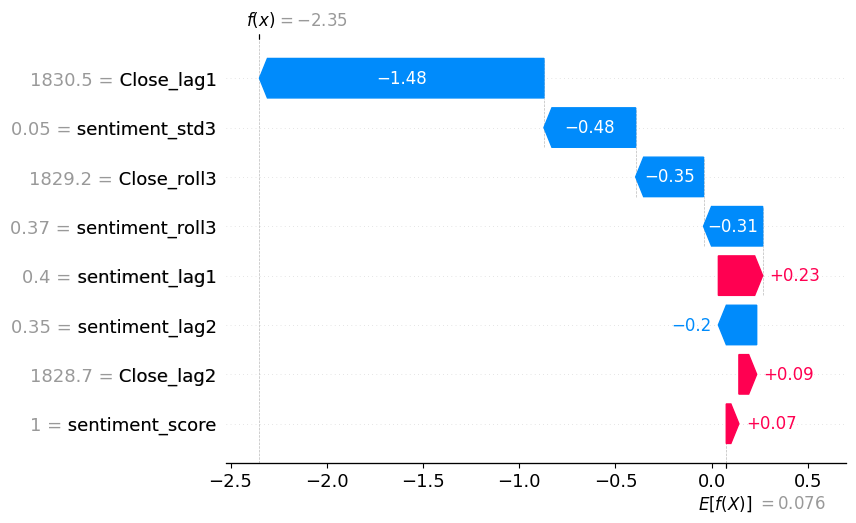

In [ ]:
# ---------------------------------------------
# GOLD PRICE DIRECTION PREDICTION WITH XGBOOST + SHAP + FINBERT
# ---------------------------------------------
import pandas as pd
import numpy as np
import shap
import torch
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from transformers import BertTokenizer, BertForSequenceClassification

# ---------------------------------------------
# STEP 1: DATA PREPARATION
# ---------------------------------------------
features = ['sentiment_score', 'sentiment_lag1', 'sentiment_lag2',
            'sentiment_roll3', 'sentiment_std3',
            'Close_lag1', 'Close_lag2', 'Close_roll3']

df["Price_Direction"] = (df["Next_Day_Close"] > df["Close"]).astype(int)

X = df[features]
y = df["Price_Direction"]

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ---------------------------------------------
# STEP 2: TRAIN BOTH MODELS
# ---------------------------------------------
# Regressor (optional reference)
reg_model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)
reg_model.fit(X_train, y_train)
y_pred_reg = reg_model.predict(X_test)

print("---- REGRESSION PERFORMANCE ----")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_reg)))
print("R2:", r2_score(y_test, y_pred_reg))

# Classifier (main model)
clf_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, use_label_encoder=False)
clf_model.fit(X_train, y_train)
y_pred_clf = clf_model.predict(X_test)

print("\n---- CLASSIFICATION PERFORMANCE ----")
print("Accuracy:", accuracy_score(y_test, y_pred_clf))
print("F1 Score:", f1_score(y_test, y_pred_clf))

# ---------------------------------------------
# STEP 3: SETUP SHAP FOR EXPLAINABILITY
# ---------------------------------------------
explainer = shap.Explainer(clf_model)

# ---------------------------------------------
# STEP 4: LOAD FINBERT FOR SENTIMENT
# ---------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = BertTokenizer.from_pretrained("yiyanghkust/finbert-tone")
finbert_model = BertForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone").to(device)

def get_finbert_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        logits = finbert_model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    sentiment = torch.argmax(probs).item()
    sentiment_map = {0: "negative", 1: "neutral", 2: "positive"}
    return sentiment_map[sentiment], probs[0][sentiment].item()

# ---------------------------------------------
# STEP 5: PREDICT NEWS IMPACT WITH EXPLANATION
# ---------------------------------------------
def predict_news_direction(news, prev_features):
    # Step 1: Sentiment analysis
    sentiment_label, sentiment_score = get_finbert_sentiment(news)

    # Step 2: Prepare input for model
    data = {**prev_features, "sentiment_score": sentiment_score}
    X_new = pd.DataFrame([data])[features]

    # Step 3: Model prediction
    pred_proba = clf_model.predict_proba(X_new)[0]
    pred_label = int(np.argmax(pred_proba))
    confidence = float(pred_proba[pred_label])

    # Step 4: SHAP explanation
    shap_values = explainer(X_new)
    feature_importance = pd.DataFrame({
        "Feature": features,
        "SHAP Value": shap_values.values[0],
        "Feature Value": X_new.values[0]
    }).sort_values(by="SHAP Value", key=abs, ascending=False)

    # Get top 3 features influencing the prediction
    top_features = feature_importance.head(3)

    # Step 5: Generate human-readable explanation
    direction_text = "UP 📈" if pred_label == 1 else "DOWN 📉"

    reasons = []
    for _, row in top_features.iterrows():
        feat, val, impact = row["Feature"], row["Feature Value"], row["SHAP Value"]
        if impact > 0:
            reasons.append(f"{feat} (+{impact:.2f}) pushed prices up")
        else:
            reasons.append(f"{feat} ({impact:.2f}) pushed prices down")

    # Build market-style explanation
    if sentiment_label == "positive":
        tone_text = "Positive sentiment may be boosting optimism."
    elif sentiment_label == "negative":
        tone_text = "Negative sentiment could be dragging expectations lower."
    else:
        tone_text = "Neutral sentiment suggests traders are waiting for signals."

    explanation = (
        f"\n📰 News: {news}\n"
        f"💬 Sentiment: {sentiment_label} ({sentiment_score:.2f})\n"
        f"📈 Predicted Direction: {direction_text} (Confidence: {confidence:.2f})\n\n"
        f"🧠 Model reasoning:\n- {reasons[0]}\n- {reasons[1]}\n- {reasons[2]}\n\n"
        f"💡 Summary: {tone_text} "
        f"The model expects {direction_text.split()[0].lower()} movement, "
        f"influenced mainly by {top_features.iloc[0]['Feature']} and {top_features.iloc[1]['Feature']}."
    )

    print(explanation)

# ---------------------------------------------
# STEP 6: TEST EXAMPLE
# ---------------------------------------------
prev_features = {
    'sentiment_lag1': 0.4,
    'sentiment_lag2': 0.35,
    'sentiment_roll3': 0.37,
    'sentiment_std3': 0.05,
    'Close_lag1': 1830.5,
    'Close_lag2': 1828.7,
    'Close_roll3': 1829.2
}

news = "Gold prices surge as global uncertainty increases"
predict_news_direction(news, prev_features)


In [7]:
import requests
from datetime import datetime

api_key = "b30c47dafbc14719873177edf61253cc"

# Refined query targeting gold-related market news
query = "(gold price OR gold market OR gold futures OR gold demand OR gold rate) AND NOT bitcoin AND NOT crypto"

# Optional: restrict to top financial sources
sources = "reuters,bloomberg,marketwatch,cnbc,financial-times"

url = (
    f"https://newsapi.org/v2/everything?"
    f"q={query}&sources={sources}&sortBy=publishedAt&language=en&pageSize=1&apiKey={api_key}"
)

response = requests.get(url).json()
article = response.get("articles", [None])[0]

if article:
    headline = article["title"]
    date = article["publishedAt"].split("T")[0]
else:
    headline = "No relevant gold news found"
    date = datetime.now().strftime("%Y-%m-%d")

print(f"Latest Gold News Headline: {headline}")
print(f"Date: {date}")


Latest Gold News Headline: Gold and Silver hit records on credit fears, US-China tensions
Date: 2025-10-17


In [ ]:
! pip uninstall typing-extensions
! pip install typing-extensions --upgrade

: 

In [5]:
! pip install yfinance


Defaulting to user installation because normal site-packages is not writeable


In [1]:
# -*- coding: utf-8 -*-
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# === Parameters ===
TICKER = "GC=F"          # Gold Futures
FALLBACK_TICKER = "GLD"  # Fallback ETF if GC=F fails
PERIOD = "max"           # e.g., "1y", "5y", "max"
OUTPUT_FILE = "gold_features.xlsx"

# === Download Data with fallback ===
gold = yf.Ticker(TICKER)
df = gold.history(period=PERIOD)
if df.empty:
    print(f"Failed to get ticker '{TICKER}', trying fallback '{FALLBACK_TICKER}'...")
    gold = yf.Ticker(FALLBACK_TICKER)
    df = gold.history(period=PERIOD)
    if df.empty:
        raise ValueError("No data found for gold. Check internet or ticker symbols.")

# --- Make index timezone-unaware ---
df.index = df.index.tz_localize(None)

# --- Basic Returns ---
df["Return"] = df["Close"].pct_change()
df["LogReturn"] = np.log(df["Close"] / df["Close"].shift(1))
for lag in range(1, 6):
    df[f"Return_lag{lag}"] = df["Return"].shift(lag)

# --- Moving Averages ---
for w in [20, 50, 100]:
    df[f"SMA{w}"] = df["Close"].rolling(window=w).mean()
    df[f"EMA{w}"] = df["Close"].ewm(span=w, adjust=False).mean()
df["EMA20_above_EMA50"] = df["EMA20"] > df["EMA50"]
df["EMA20_below_EMA50"] = df["EMA20"] < df["EMA50"]

# --- RSI (14 days) ---
delta = df["Close"].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)
avg_gain = pd.Series(gain).rolling(14).mean()
avg_loss = pd.Series(loss).rolling(14).mean()
rs = avg_gain / avg_loss
df["RSI14"] = 100 - (100 / (1 + rs))

# --- MACD ---
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD_Line"] = ema12 - ema26
df["MACD_Signal"] = df["MACD_Line"].ewm(span=9, adjust=False).mean()
df["MACD_Histogram"] = df["MACD_Line"] - df["MACD_Signal"]

# --- Stochastic Oscillator ---
low14 = df["Low"].rolling(14).min()
high14 = df["High"].rolling(14).max()
df["Stochastic_%K"] = 100 * ((df["Close"] - low14) / (high14 - low14))
df["Stochastic_%D"] = df["Stochastic_%K"].rolling(3).mean()

# --- Volatility Measures ---
df["Volatility_5d"] = df["Return"].rolling(5).std()
df["Volatility_10d"] = df["Return"].rolling(10).std()
df["Volatility_20d"] = df["Return"].rolling(20).std()
tr = pd.concat([
    df["High"] - df["Low"],
    (df["High"] - df["Close"].shift()).abs(),
    (df["Low"] - df["Close"].shift()).abs()
], axis=1).max(axis=1)
df["ATR14"] = tr.rolling(14).mean()

# --- Bollinger Bands ---
rolling_mean = df["Close"].rolling(20).mean()
rolling_std = df["Close"].rolling(20).std()
df["BB_Upper"] = rolling_mean + (2 * rolling_std)
df["BB_Lower"] = rolling_mean - (2 * rolling_std)
df["BB_Width"] = df["BB_Upper"] - df["BB_Lower"]
df["BB_Position"] = (df["Close"] - df["BB_Lower"]) / (df["BB_Upper"] - df["BB_Lower"])

# --- Rule-based Signals ---
df["Signal_EMA_Buy"] = df["EMA20"] > df["EMA50"]
df["Signal_EMA_Sell"] = df["EMA20"] < df["EMA50"]
df["Signal_RSI_Buy"] = df["RSI14"] < 30
df["Signal_RSI_Sell"] = df["RSI14"] > 70
df["Signal_MACD_Bullish"] = df["MACD_Line"] > df["MACD_Signal"]
df["Signal_MACD_Bearish"] = df["MACD_Line"] < df["MACD_Signal"]
df["Signal_BB_Buy"] = df["Close"] < df["BB_Lower"]
df["Signal_BB_Sell"] = df["Close"] > df["BB_Upper"]

# --- Probabilistic Features ---
def momentum_bucket(r):
    if r > 0.002: return "Up"
    elif r < -0.002: return "Down"
    else: return "Neutral"
df["Momentum_Bucket"] = df["Return"].apply(momentum_bucket)

vol20 = df["Return"].rolling(20).std()
q_low, q_high = vol20.quantile([0.33, 0.66])
def vol_bucket(v):
    if v <= q_low: return "Low"
    elif v <= q_high: return "Medium"
    else: return "High"
df["Volatility_Bucket"] = vol20.apply(vol_bucket)
df["Trend_Flag"] = np.where(df["Close"] > df["EMA50"], "Up", "Down")

# --- Normalized Features ---
features_to_normalize = [
    "Open","High","Low","Close","Volume","EMA20","EMA50",
    "RSI14","MACD_Line","MACD_Signal","MACD_Histogram",
    "BB_Position","Return"
]
knn_df = df[features_to_normalize].copy().dropna(thresh=len(features_to_normalize)-3)
knn_df = knn_df.ffill().fillna(0)
scaler = StandardScaler()
scaled_values = scaler.fit_transform(knn_df)
for i, col in enumerate(features_to_normalize):
    df[f"{col}_scaled"] = pd.Series(scaled_values[:, i], index=knn_df.index)

# --- Next-day target ---
df["Target_NextDay"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# === Save to Excel ===
df.to_excel(OUTPUT_FILE)
print(f"✅ Gold features saved to {OUTPUT_FILE}")


ModuleNotFoundError: No module named 'yfinance'

In [6]:
import sys
print(sys.executable)


c:\Users\dhava\AppData\Local\Programs\Python\Python313\python.exe


In [7]:
! c:\Users\dhava\AppData\Local\Programs\Python\Python313\python.exe -m pip install openpyxl



   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [8]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("gold_features.xlsx")

# Show the first 5 rows
print(df.head())


        Date        Open        High         Low       Close  Volume  \
0 2000-08-30  273.899994  273.899994  273.899994  273.899994       0   
1 2000-08-31  274.799988  278.299988  274.799988  278.299988       0   
2 2000-09-01  277.000000  277.000000  277.000000  277.000000       0   
3 2000-09-05  275.799988  275.799988  275.799988  275.799988       2   
4 2000-09-06  274.200012  274.200012  274.200012  274.200012       0   

   Dividends  Stock Splits    Return  LogReturn  ...  Volume_scaled  \
0          0             0       NaN        NaN  ...      -0.177925   
1          0             0  0.016064   0.015937  ...      -0.177925   
2          0             0 -0.004671  -0.004682  ...      -0.177925   
3          0             0 -0.004332  -0.004342  ...      -0.177842   
4          0             0 -0.005801  -0.005818  ...      -0.177925   

   EMA20_scaled  EMA50_scaled  RSI14_scaled  MACD_Line_scaled  \
0     -1.404987     -1.414016             0         -0.239967   
1     -1.4

In [9]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Return', 'LogReturn', 'Return_lag1', 'Return_lag2',
       'Return_lag3', 'Return_lag4', 'Return_lag5', 'SMA20', 'EMA20', 'SMA50',
       'EMA50', 'SMA100', 'EMA100', 'EMA20_above_EMA50', 'EMA20_below_EMA50',
       'RSI14', 'MACD_Line', 'MACD_Signal', 'MACD_Histogram', 'Stochastic_%K',
       'Stochastic_%D', 'Volatility_5d', 'Volatility_10d', 'Volatility_20d',
       'ATR14', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position',
       'Signal_EMA_Buy', 'Signal_EMA_Sell', 'Signal_RSI_Buy',
       'Signal_RSI_Sell', 'Signal_MACD_Bullish', 'Signal_MACD_Bearish',
       'Signal_BB_Buy', 'Signal_BB_Sell', 'Momentum_Bucket',
       'Volatility_Bucket', 'Trend_Flag', 'Open_scaled', 'High_scaled',
       'Low_scaled', 'Close_scaled', 'Volume_scaled', 'EMA20_scaled',
       'EMA50_scaled', 'RSI14_scaled', 'MACD_Line_scaled',
       'MACD_Signal_scaled', 'MACD_Histogram_scaled', 'BB_Position_scaled',
  